In [1]:
import pandas as pd
import csv

In [2]:
def parse_params(params_str):
    params = {}
    for item in params_str.split():
        if '=' in item:
            key, value = item.split('=', 1)
            params[key] = value
    return params

# aggregates results over all parameters except those in params_to_compare
def results_csv_to_df(csv_file, params_to_aggregate=None):
    results = []

    with open(csv_file, newline='') as f:
        reader = csv.DictReader(f, fieldnames=[
            'accuracy', 'correctly_filled_cells', 'nfe', 'time', 'speed', 'not_fully_unmasked',
            'checkpoint', 'strategy', 'params'
        ])
        reader.__next__()  # Skip header row
        for row in reader:
            params = parse_params(row['params'])
            row_dict = {
                'accuracy': float(row['accuracy']),
                'correctly_filled_cells': float(row['correctly_filled_cells']),
                'checkpoint': row['checkpoint'],
                'strategy': row['strategy'],
                'nfe': float(row['nfe']),
                'time': float(row['time']),
                'speed': float(row['speed']),
            }
            row_dict.update(params.items())
            results.append(row_dict)
    
    results_df = pd.DataFrame(results)
    print(f"Total rows before aggregation: {len(results_df)}")
    
    # Aggregate the accuracy, correctly_filled_cells, nfe, time, and speed over the rows where all parameters except those in params_to_aggregate are the same
    if params_to_aggregate is not None:
        groupby_cols = [col for col in results_df.columns if col not in params_to_aggregate + ['accuracy', 'correctly_filled_cells', 'nfe', 'time', 'speed']]
    else:
        groupby_cols = [col for col in results_df.columns if col not in ['accuracy', 'correctly_filled_cells', 'nfe', 'time', 'speed']]
    
    aggregated_df = results_df.groupby(groupby_cols, dropna=False).agg(
        accuracy_mean=pd.NamedAgg(column='accuracy', aggfunc='mean'),
        accuracy_std=pd.NamedAgg(column='accuracy', aggfunc='std'),
        correctly_filled_cells_mean=pd.NamedAgg(column='correctly_filled_cells', aggfunc='mean'),
        correctly_filled_cells_std=pd.NamedAgg(column='correctly_filled_cells', aggfunc='std'),
        nfe=pd.NamedAgg(column='nfe', aggfunc='mean'),
        time=pd.NamedAgg(column='time', aggfunc='mean'),
        speed=pd.NamedAgg(column='speed', aggfunc='mean'),
    ).reset_index()

    print(f"Rows after aggregation: {len(aggregated_df)}")
    return aggregated_df

In [3]:
params_to_aggregate = ['seed']
df = results_csv_to_df('results_reproduce_part_1.csv', params_to_aggregate=params_to_aggregate)
df

Total rows before aggregation: 86
Rows after aggregation: 86


,checkpoint,strategy,unmask_token,dataset,num_samples,num_denoising_steps,num_self_correction_steps,time_steps,batch_size,min_p,...,score_time,score_method,initiate_beam_search_after_progress,accuracy_mean,accuracy_std,correctly_filled_cells_mean,correctly_filled_cells_std,nfe,time,speed
0,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,NaN,hard,6400,80,0,inferred,1,0,...,inferred,avg,0.0,0.6937,NaN,0.8597,NaN,89.73,7750.0,0.83
1,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,NaN,hard,6400,80,0,inferred,1,0,...,inferred,avg,0.2,0.6937,NaN,0.8597,NaN,87.47,7587.0,0.84
2,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,NaN,hard,6400,80,0,inferred,1,0,...,inferred,avg,0.5,0.6820,NaN,0.8547,NaN,79.85,6976.0,0.92
3,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,NaN,hard,6400,80,0,inferred,1,0,...,inferred,avg,0.0,0.6816,NaN,0.8546,NaN,76.36,6637.0,0.96
4,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,NaN,hard,6400,80,0,inferred,1,0,...,inferred,avg,0.2,0.6816,NaN,0.8546,NaN,74.11,6393.0,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,checkpoints/mdlm/300_epochs,mdlm_vanilla,MDM_max,hard,6400,10,0,fixed,64,0,...,NaN,NaN,NaN,0.0420,NaN,0.6103,NaN,0.15,18.0,360.20
82,checkpoints/mdlm/300_epochs,mdlm_vanilla,MDM_max,hard,6400,20,0,fixed,64,0,...,NaN,NaN,NaN,0.0702,NaN,0.6151,NaN,0.30,31.0,204.13
83,checkpoints/mdlm/300_epochs,mdlm_vanilla,MDM_max,hard,6400,40,0,fixed,64,0,...,NaN,NaN,NaN,0.0811,NaN,0.6136,NaN,0.61,61.0,104.39
84,checkpoints/mdlm/300_epochs,mdlm_vanilla,MDM_max,hard,6400,5,0,fixed,64,0,...,NaN,NaN,NaN,0.0131,NaN,0.6132,NaN,0.07,10.0,654.75


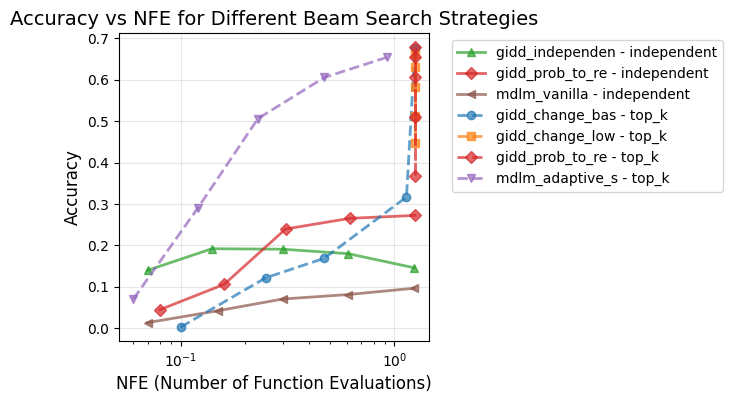

In [4]:
# Plot accuracy vs NFE for each strategy with two lines per strategy (avg and min score_method)
import matplotlib.pyplot as plt

# Filter data
filtered_data = df
# filtered_data = df[df['do_beam_search'] == 'true']
filtered_data = df[df['do_beam_search'] == 'false']

# Create the plot
plt.figure(figsize=(4, 4))

# Get unique strategies and checkpoints for plotting
strategies = filtered_data['strategy'].unique()
checkpoints = filtered_data['checkpoint'].unique()
df_by_category = {
    'independent': filtered_data[
        (filtered_data['strategy'].isin(['mdlm_vanilla', 'gidd_independent_positions_decomposed_update_distribution'])) |
        ((filtered_data['strategy'] == 'gidd_prob_to_recover_data') & (filtered_data['position_sampling'] == 'independent'))
    ],
    'top_k': filtered_data[
        (
            (filtered_data['strategy'].isin(['mdlm_adaptive_score_select_update', 'gidd_change_low_confidence_positions', 'gidd_change_based_on_model_confidence_to_change'])) |
            ((filtered_data['strategy'] == 'gidd_prob_to_recover_data') & (filtered_data['position_sampling'] == 'top_k'))
        ) & (filtered_data['do_beam_search'] == 'false')
    ],
    'beam_search': filtered_data[
        (filtered_data['do_beam_search'] == 'true')
    ]
}

# Use different markers and colors for each strategy-checkpoint combination
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
colors = plt.cm.tab10(range(len(strategies) * len(checkpoints)))
strategies_to_index = {strategy: idx for idx, strategy in enumerate(strategies)}


def plot_subset(subset, category, strategy, strategy_color, marker, linestyle):
    if not subset.empty:
        # Sort by NFE for proper line connection
        subset_sorted = subset.sort_values('nfe')
        label = f'{strategy[:15]} - {category}'
        plt.plot(subset_sorted['nfe'], subset_sorted['accuracy_mean'], 
                label=label,
                marker=marker,
                color=strategy_color,
                linestyle=linestyle,
                markersize=6, alpha=0.7, linewidth=2)

for category, category_data in df_by_category.items():
    if len(category_data) == 0:
        continue
    # print('a')
    current_strategies = category_data['strategy'].unique()
    current_checkpoints = category_data['checkpoint'].unique()
    for strategy in current_strategies:
        # print('b')
        for checkpoint in current_checkpoints:
            strategy_color = colors[strategies_to_index[strategy]]
            subset = category_data[
                (category_data['strategy'] == strategy) & 
                (category_data['checkpoint'] == checkpoint)
            ]
            if len(subset) == 0:
                continue
            # print('c')
            if category == 'beam_search':
                linestyles = ['-', '--', ':']
                for i, beam_search_start in enumerate(['0.0', '0.2', '0.5']):
                    current_subset = subset[subset['initiate_beam_search_after_progress'] == beam_search_start]
                    # print('d')
                    # print(f"Plotting {strategy} - {category} - beam start {beam_search_start} with {len(subset)} points")
                    plot_subset(current_subset, category, strategy, strategy_color, markers[strategies_to_index[strategy] % len(markers)], linestyles[i])
            else:
                # print('e')
                match category:
                    case 'independent':
                        linestyle = '-'
                    case 'top_k':
                        linestyle = '--'
                plot_subset(subset, category, strategy, strategy_color, markers[strategies_to_index[strategy] % len(markers)], linestyle)
            
            

plt.xlabel('NFE (Number of Function Evaluations)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs NFE for Different Beam Search Strategies', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xscale('log')
# plt.tight_layout()
plt.show()


/tmp/ipykernel_2817276/2114410593.py:46: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


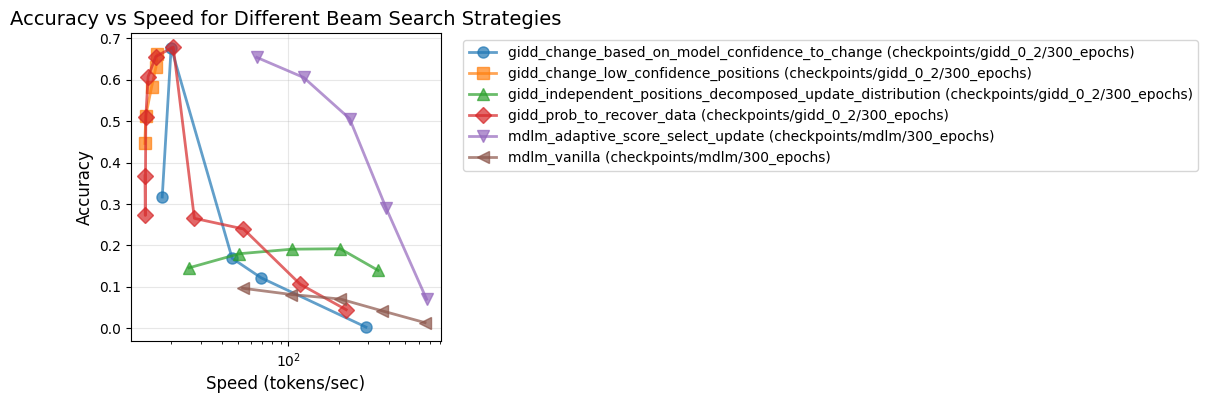

In [5]:
# Plot accuracy vs speed for each strategy with specific filtering
import matplotlib.pyplot as plt

# Filter data based on the specified conditions (same as previous plot)
filtered_data = df
# filtered_data = df[df['do_beam_search'] == 'true']
filtered_data = df[df['do_beam_search'] == 'false']

# Create the plot
plt.figure(figsize=(4, 4))

# Get unique strategies for plotting
strategies = filtered_data['strategy'].unique()
checkpoints = filtered_data['checkpoint'].unique()

# Use different markers and colors for each strategy-checkpoint combination
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
colors = plt.cm.tab10(range(len(strategies) * len(checkpoints)))

plot_idx = 0
for strategy in strategies:
    for checkpoint in checkpoints:
        subset = filtered_data[
            (filtered_data['strategy'] == strategy) & 
            (filtered_data['checkpoint'] == checkpoint)
        ]
        
        if not subset.empty:
            # Sort by speed for proper line connection
            subset_sorted = subset.sort_values('speed')
            
            plt.plot(subset_sorted['speed'], subset_sorted['accuracy_mean'], 
                    label=f'{strategy} ({checkpoint})',
                    marker=markers[plot_idx % len(markers)],
                    color=colors[plot_idx],
                    markersize=8, alpha=0.7, linewidth=2)
            
            plot_idx += 1

plt.xlabel('Speed (tokens/sec)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs Speed for Different Beam Search Strategies', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xscale('log')
plt.tight_layout()
plt.show()
